In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, pairwise_distances
import seaborn as sns
from torchvision.models import resnet18
import copy
import os

In [2]:

# Configuração de ambiente
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True

In [3]:

# Hiperparâmetros globais
BATCH_SIZE = 64
VAL_SPLIT = 0.1
NUM_CLASSES = 10
IMG_SIZE = 224
DROP_RATES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
# DROP_RATES = [0.0]

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Configuração para testes rápidos
DEBUG = False
SUBSET_RATIO = 0.01  # Usa 10% da base em modo debug
DATASET_CLS = torchvision.datasets.MNIST  # ou torchvision.datasets.FashionMNIST

# Carregamento da base
full_train = DATASET_CLS(root="./data/artigo3", train=True, download=True, transform=transform)
full_test = DATASET_CLS(root="./data/artigo3", train=False, download=True, transform=transform)

if DEBUG:
    subset_size = int(len(full_train) * SUBSET_RATIO)
    test_subset_size = int(len(full_test) * SUBSET_RATIO)

    full_train = torch.utils.data.Subset(full_train, range(subset_size))
    full_test = torch.utils.data.Subset(full_test, range(test_subset_size))

# Split em treino e validação
val_size = int(len(full_train) * VAL_SPLIT)
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(full_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)



def get_lenet5_model(dropout_value):
    model = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5),    # 28x28 → 24x24
        nn.ReLU(),
        nn.MaxPool2d(2, 2),                # 24x24 → 12x12
        nn.Conv2d(6, 16, kernel_size=5),   # 12x12 → 8x8
        nn.ReLU(),
        nn.MaxPool2d(2, 2),                # 8x8 → 4x4
        nn.Flatten(),                     # 16*4*4 = 256
        nn.Linear(256, 120),
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Dropout(p=dropout_value),
        nn.Linear(84, NUM_CLASSES)
    )
    return model.to(device)



from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(dataloader, desc="Train", leave=False)
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(dataloader, desc="Val", leave=False)
    with torch.no_grad():
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc



def early_stopping(val_losses, patience=3):
    if len(val_losses) < patience + 1:
        return False
    recent = val_losses[-(patience + 1):]
    return all(recent[i] <= recent[i + 1] for i in range(patience))

def extract_embeddings(model, dataloader, dropout_value, save_dir="data/artigo3/embeddings", filename=None):
    model.eval()
    os.makedirs(save_dir, exist_ok=True)

    embeddings = []
    labels = []

    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc=f"Extraindo embeddings dropout={dropout_value}"):
            inputs = inputs.to(device)

            # Forward até a penúltima camada (antes do fc3)
            x = model[0](inputs)  # Conv1
            x = model[1](x)       # ReLU
            x = model[2](x)       # Pool
            x = model[3](x)       # Conv2
            x = model[4](x)       # ReLU
            x = model[5](x)       # Pool
            x = model[6](x)       # Flatten
            x = model[7](x)       # FC1
            x = model[8](x)       # ReLU
            x = model[9](x)       # FC2
            x = model[10](x)      # ReLU

            embeddings.append(x.cpu())
            labels.append(targets)

    embeddings = torch.cat(embeddings, dim=0)
    labels = torch.cat(labels, dim=0)

    if filename is None:
        filename = f"embeddings_dropout_{dropout_value}.pt"
    torch.save({'embeddings': embeddings, 'labels': labels},
               os.path.join(save_dir, filename))
    print(f"> Embeddings salvos em {filename}")

In [15]:
# Bloco 5 – Treinamento com controle de tempo e salvamento por dropout

import time
import os

MAX_EPOCHS = 25
PATIENCE = 3
LEARNING_RATE = 1e-3
MODEL_DIR = "data/artigo3/models"
os.makedirs(MODEL_DIR, exist_ok=True)

results = {}

import csv

EMBEDDINGS_DIR = "data/artigo3/embeddings"
os.makedirs(EMBEDDINGS_DIR, exist_ok=True)

val_acc_history = []

for dropout in DROP_RATES:
    print(f"\n===== Dropout {dropout} =====")

    suffix = "_debug" if DEBUG else ""
    model_path = os.path.join(MODEL_DIR, f"lenet5_dropout_{dropout}{suffix}.pth")

    # Se já existe modelo salvo, pula o treino
    if os.path.exists(model_path):
        print(f"> Modelo já salvo em {model_path}, pulando treino.")
        model = get_lenet5_model(dropout)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        results[dropout] = {'trained': False}
        continue

    model = get_lenet5_model(dropout)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    val_losses = []
    best_val_loss = float('inf')
    best_model_wts = None

    start_time = time.time()
    for epoch in tqdm(range(MAX_EPOCHS), desc=f"Treinando Dropout {dropout}"):
        epoch_start_time = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Salva modelo da época
        epoch_model_path = os.path.join(
            MODEL_DIR, f"model_dropout_{dropout}epoch{epoch+1}.pth"
        )
        torch.save(model.state_dict(), epoch_model_path)

        # Extrai e salva embeddings do conjunto de validação
        embeddings_filename = f"embeddings_dropout_{dropout}epoch{epoch+1}acc{val_acc:.4f}.pt"
        embeddings_path = os.path.join(EMBEDDINGS_DIR, embeddings_filename)
        extract_embeddings(model, val_loader, dropout_value=dropout, save_dir=EMBEDDINGS_DIR, filename=embeddings_filename)

        # Registra histórico de acurácia
        epoch_time = time.time() - epoch_start_time
        val_acc_history.append({
            'dropout': dropout,
            'epoch': epoch+1,
            'val_acc': val_acc,
            'epoch_time': epoch_time
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = model.state_dict()

        if early_stopping(val_losses, patience=PATIENCE):
            print("Early stopping triggered.")
            break

    elapsed = time.time() - start_time
    print(f"> Tempo total de treino: {elapsed:.1f} segundos")

    # Salva modelo com melhores pesos
    torch.save(best_model_wts, model_path)
    print(f"> Modelo salvo em {model_path}")

    results[dropout] = {
        'trained': True,
        'epochs': len(val_losses),
        'time': elapsed
    }

# Salva histórico de acurácia em CSV
import pandas as pd
df = pd.DataFrame(val_acc_history)
df.to_csv(os.path.join(MODEL_DIR, "val_acc_history.csv"), index=False)
print("> Histórico de acurácia salvo em val_acc_history.csv")



===== Dropout 0.0 =====


Treinando Dropout 0.0:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.2348 Acc: 0.9316 | Val Loss: 0.0828 Acc: 0.9748


Treinando Dropout 0.0:   4%|▍         | 1/25 [01:17<31:09, 77.91s/it]

> Embeddings salvos em embeddings_dropout_0.0epoch1acc0.9748.pt


...

Treinando Dropout 0.5:  64%|██████▍   | 16/25 [23:52<13:14, 88.33s/it]

> Embeddings salvos em embeddings_dropout_0.5epoch16acc0.9865.pt


Epoch 17 | Train Loss: 0.0139 Acc: 0.9958 | Val Loss: 0.0631 Acc: 0.9885


Treinando Dropout 0.5:  64%|██████▍   | 16/25 [25:25<14:17, 95.31s/it]

> Embeddings salvos em embeddings_dropout_0.5epoch17acc0.9885.pt
Early stopping triggered.
> Tempo total de treino: 1525.0 segundos
> Modelo salvo em data/artigo3/models/lenet5_dropout_0.5.pth
> Histórico de acurácia salvo em val_acc_history.csv


In [5]:
import torch
import pandas as pd
import os
import re
from tqdm import tqdm

EMBEDDINGS_DIR = "data/artigo3/embeddings"

# Regex para extrair dropout, epoch e acurácia do nome do arquivo
pattern = re.compile(r'embeddings_dropout_([0-9.]+)epoch([0-9]+)acc([0-9.]+)\.pt')

# Lista todos os arquivos de embeddings
embedding_files = [f for f in os.listdir(EMBEDDINGS_DIR) if f.endswith('.pt') and 'epoch' in f and 'acc' in f]

# Lista para armazenar os dados
all_rows = []

for fname in tqdm(embedding_files):
    match = pattern.match(fname)
    if not match:
        continue
    dropout, epoch, val_acc = match.groups()
    data = torch.load(os.path.join(EMBEDDINGS_DIR, fname), map_location='cpu')
    embeddings = data['embeddings']  # (N, D)
    labels = data['labels']          # (N,)
    for emb, label in zip(embeddings, labels):
        all_rows.append({
            'dropout': float(dropout),
            'epoch': int(epoch),
            'val_acc': float(val_acc),
            'label': int(label),
            'embedding': emb.numpy()  # ou emb.tolist() se preferir listas puras
        })

# Cria o DataFrame
df = pd.DataFrame(all_rows)

100%|██████████| 112/112 [00:17<00:00,  6.49it/s]


In [6]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np

def calc_metrics(labels, embeddings):
    X = np.stack(embeddings)
    y = np.array(labels)
    if len(np.unique(y)) < 2 or len(y) < 2:
        return np.nan, np.nan, np.nan
    return (
        silhouette_score(X, y),
        calinski_harabasz_score(X, y),
        davies_bouldin_score(X, y)
    )

df_results = (
    df.groupby(['dropout', 'epoch'], sort=False)
      .agg(
          val_acc=('val_acc', 'first'),
          labels=('label', list),
          embeddings=('embedding', list)
      )
      .reset_index()
)

df_results[['silhouette', 'calinski', 'davies']] = df_results.apply(
    lambda row: calc_metrics(row['labels'], row['embeddings']), axis=1, result_type='expand'
)

In [7]:
df_results.drop(columns=['labels', 'embeddings'],inplace=True)

Gráfico de dispersão corrigido salvo em: imagens/artigo3/scatter_metricas_vs_acuracia.png


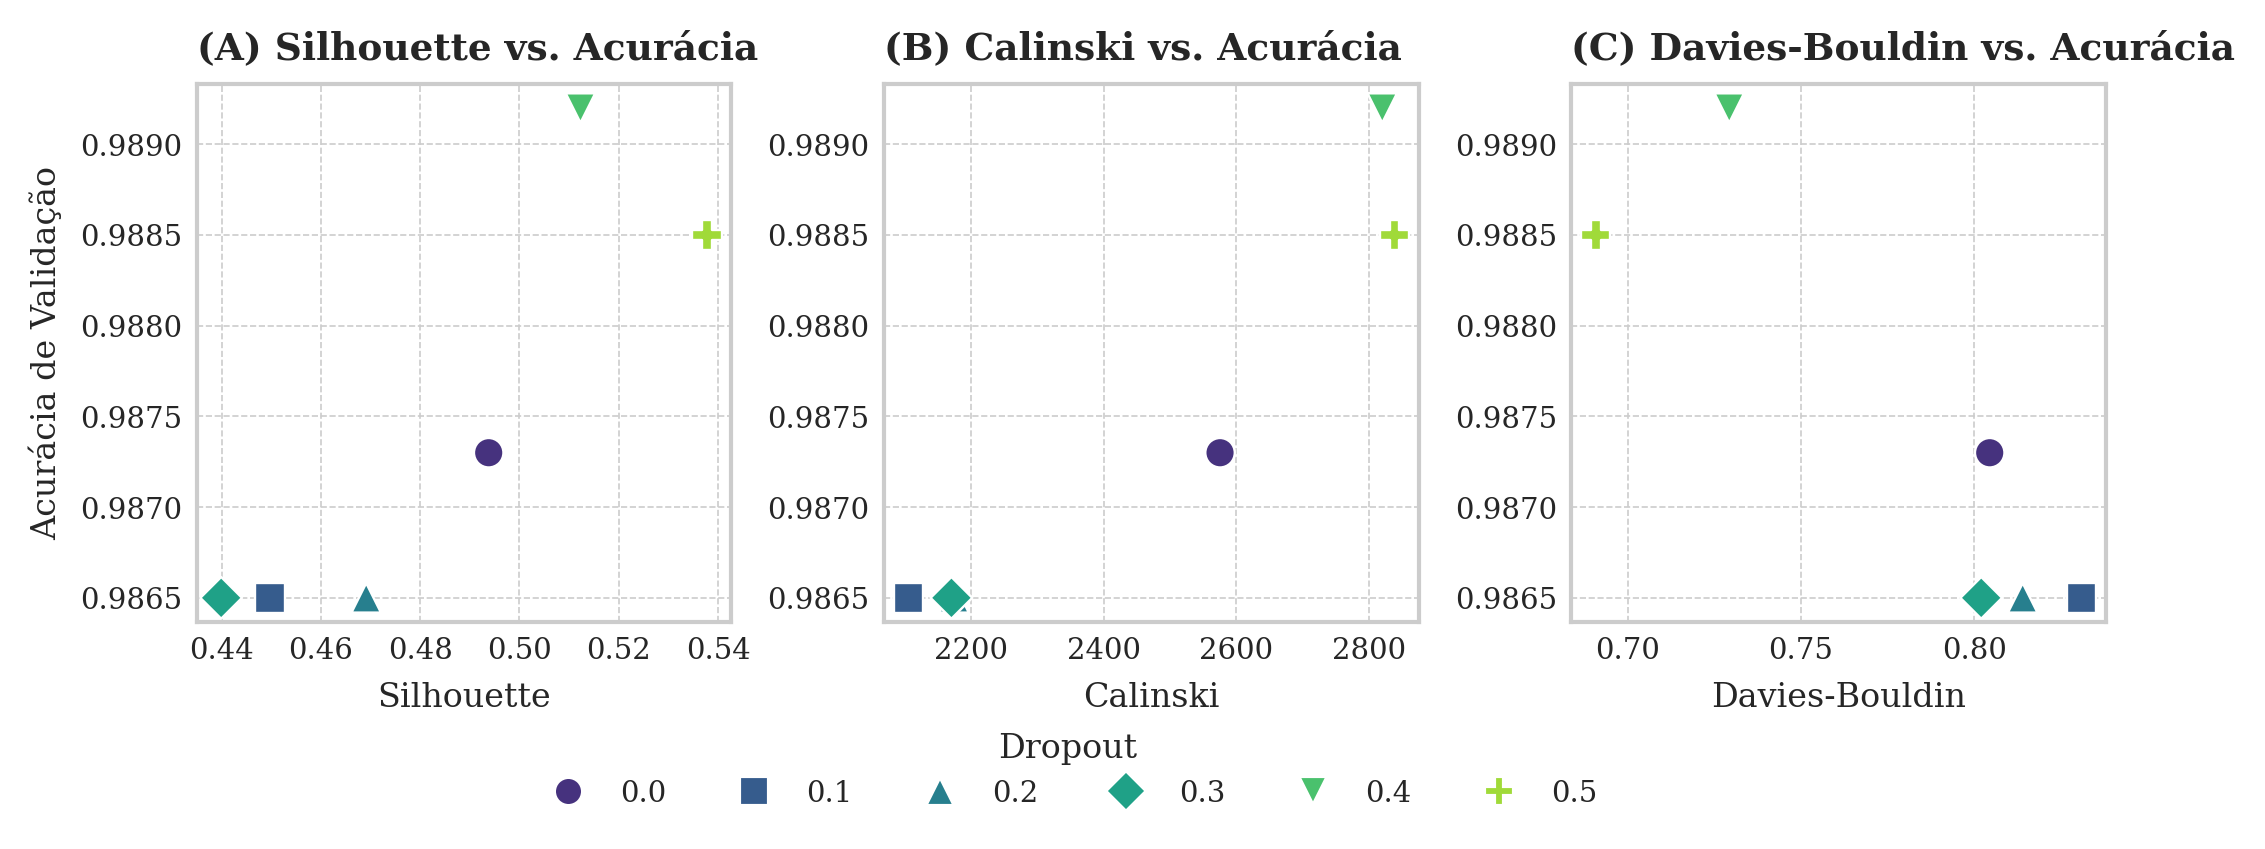

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from matplotlib.lines import Line2D # Importa a classe para criar handles de legenda

# --- 1. Configurações para o Padrão IEEE ---
output_dir = "imagens/artigo3"
os.makedirs(output_dir, exist_ok=True)

# Estilo e fontes para publicação
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='serif', size=8)
plt.rc('axes', titlesize=9, labelsize=8)
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)
plt.rc('legend', fontsize=7, title_fontsize=8)

# --- 2. Preparação dos Dados e Métricas ---
df_last = df_results.loc[df_results.groupby('dropout')['epoch'].idxmax()]

metrics = ['silhouette', 'calinski', 'davies']
metric_labels = {
    'silhouette': 'Silhouette',
    'calinski': 'Calinski',
    'davies': 'Davies-Bouldin'
}
dropouts = sorted(df_last['dropout'].unique())

# --- 3. Criação do Gráfico ---
fig, axes = plt.subplots(1, 3, figsize=(7.16, 2.8), dpi=300)

# Define paleta de cores e marcadores para consistência
palette = sns.color_palette("viridis", n_colors=len(dropouts))
markers = ['o', 's', '^', 'D', 'v', 'P']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.scatterplot(
        data=df_last,
        x=metric,
        y='val_acc',
        hue='dropout',
        style='dropout',
        hue_order=dropouts, # Garante a ordem correta
        style_order=dropouts,
        markers=markers[:len(dropouts)],
        palette=palette,
        s=50,
        ax=ax,
        legend=False # Desativa a legenda automática
    )
    ax.set_xlabel(metric_labels[metric])
    ax.set_ylabel('Acurácia de Validação' if i == 0 else '')
    ax.set_title(f'({chr(65+i)}) {metric_labels[metric]} vs. Acurácia', loc='left', weight='bold')
    ax.grid(True, which='both', linestyle='--', linewidth=0.4)

# --- 4. Criação Manual da Legenda Compartilhada ---
legend_handles = []
for i, val in enumerate(dropouts):
    handle = Line2D([0], [0], marker=markers[i], color='w',
                    markerfacecolor=palette[i], markersize=7,
                    label=f'{val:.1f}')
    legend_handles.append(handle)

fig.legend(handles=legend_handles, title='Dropout', ncol=len(dropouts),
           loc='lower center', bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# --- 5. Salvar a Figura ---
file_path = os.path.join(output_dir, "scatter_metricas_vs_acuracia.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

print(f"Gráfico de dispersão corrigido salvo em: {file_path}")
plt.show()

# Importante: Reseta as configurações do matplotlib
plt.rcdefaults()


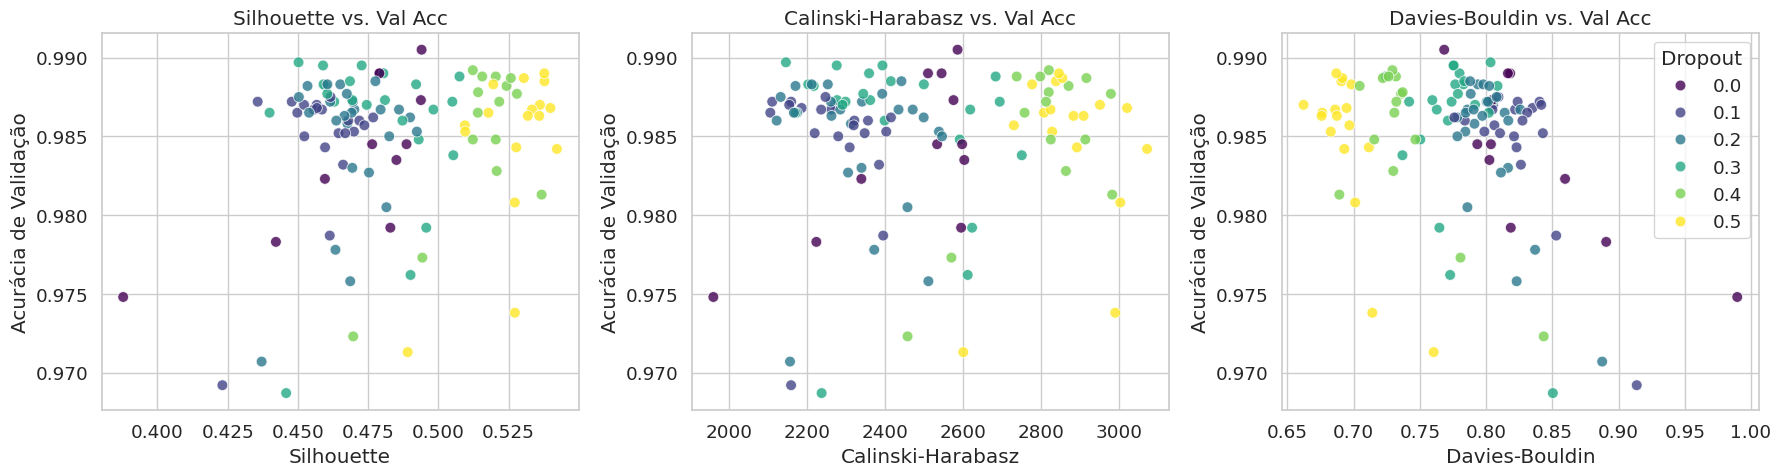

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo
sns.set(style="whitegrid", font_scale=1.2)

metrics = ['silhouette', 'calinski', 'davies']
metric_labels = {
    'silhouette': 'Silhouette',
    'calinski': 'Calinski-Harabasz',
    'davies': 'Davies-Bouldin'
}

plt.figure(figsize=(18, 5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    scatter = sns.scatterplot(
        data=df_results,
        x=metric, y='val_acc',
        hue='dropout', palette='viridis', s=60, alpha=0.8
    )
    plt.xlabel(metric_labels[metric])
    plt.ylabel('Acurácia de Validação')
    plt.title(f'{metric_labels[metric]} vs. Val Acc')
    if i == 2:
        plt.legend(title='Dropout')
    else:
        plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

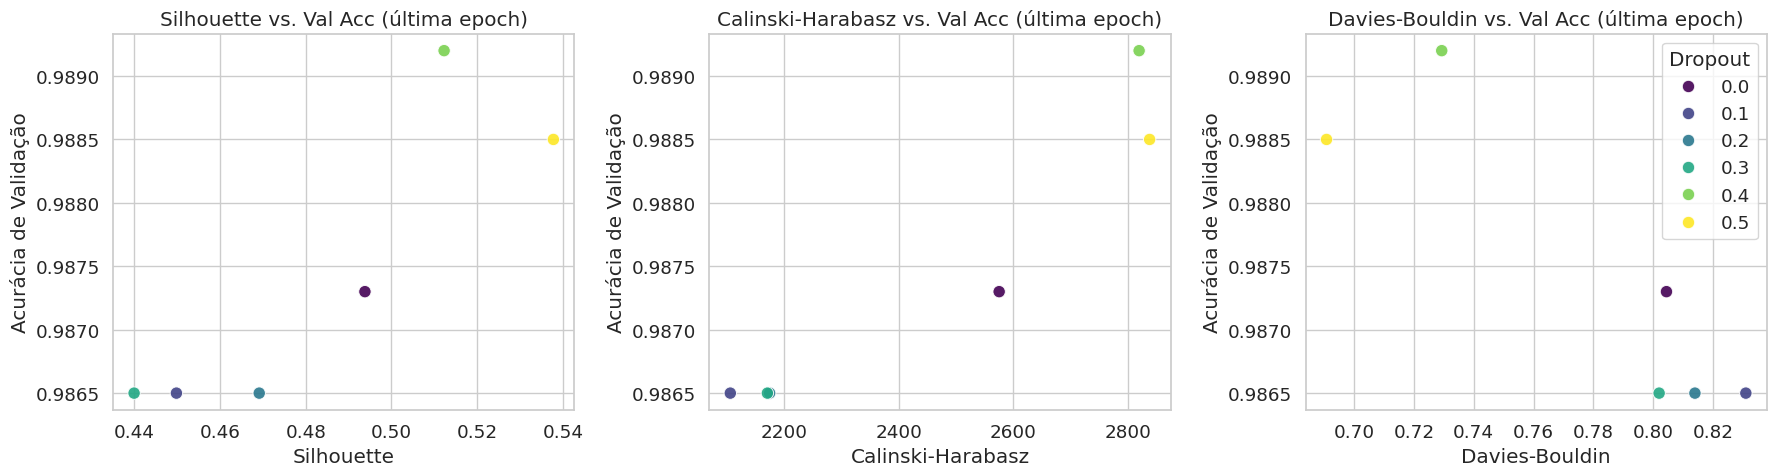

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleciona apenas a última epoch de cada dropout
df_last = df_results.loc[df_results.groupby('dropout')['epoch'].idxmax()]

metrics = ['silhouette', 'calinski', 'davies']
metric_labels = {
    'silhouette': 'Silhouette',
    'calinski': 'Calinski-Harabasz',
    'davies': 'Davies-Bouldin'
}

plt.figure(figsize=(18, 5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    scatter = sns.scatterplot(
        data=df_last,
        x=metric, y='val_acc',
        hue='dropout', palette='viridis', s=80, alpha=0.9
    )
    plt.xlabel(metric_labels[metric])
    plt.ylabel('Acurácia de Validação')
    plt.title(f'{metric_labels[metric]} vs. Val Acc (última epoch)')
    if i == 2:
        plt.legend(title='Dropout')
    else:
        plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import pearsonr

# Seleciona a última epoch de cada dropout
df_last = df_results.loc[df_results.groupby('dropout')['epoch'].idxmax()]

for metric in ['silhouette', 'calinski', 'davies']:
    corr, pval = pearsonr(df_last[metric], df_last['val_acc'])
    print(f"Correlação de Pearson entre val_acc e {metric}: {corr:.3f} (p-valor={pval:.3g})")

Correlação de Pearson entre val_acc e silhouette: 0.871 (p-valor=0.0239)
Correlação de Pearson entre val_acc e calinski: 0.949 (p-valor=0.00384)
Correlação de Pearson entre val_acc e davies: -0.885 (p-valor=0.0189)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

for metric in ['silhouette', 'calinski', 'davies']:
    X = df_last[[metric]].values
    y = df_last['val_acc'].values
    reg = LinearRegression().fit(X, y)
    y_pred = reg.predict(X)
    r2 = r2_score(y, y_pred)
    print(f"Regressão: {metric} -> val_acc | R² = {r2:.3f} | Coef = {reg.coef_[0]:.3f} | Intercepto = {reg.intercept_:.3f}")

Regressão: silhouette -> val_acc | R² = 0.759 | Coef = 0.027 | Intercepto = 0.974
Regressão: calinski -> val_acc | R² = 0.901 | Coef = 0.000 | Intercepto = 0.979
Regressão: davies -> val_acc | R² = 0.784 | Coef = -0.019 | Intercepto = 1.002


Gráfico aprimorado salvo em: imagens/artigo3/metricas_evolucao_vs_epoca.png


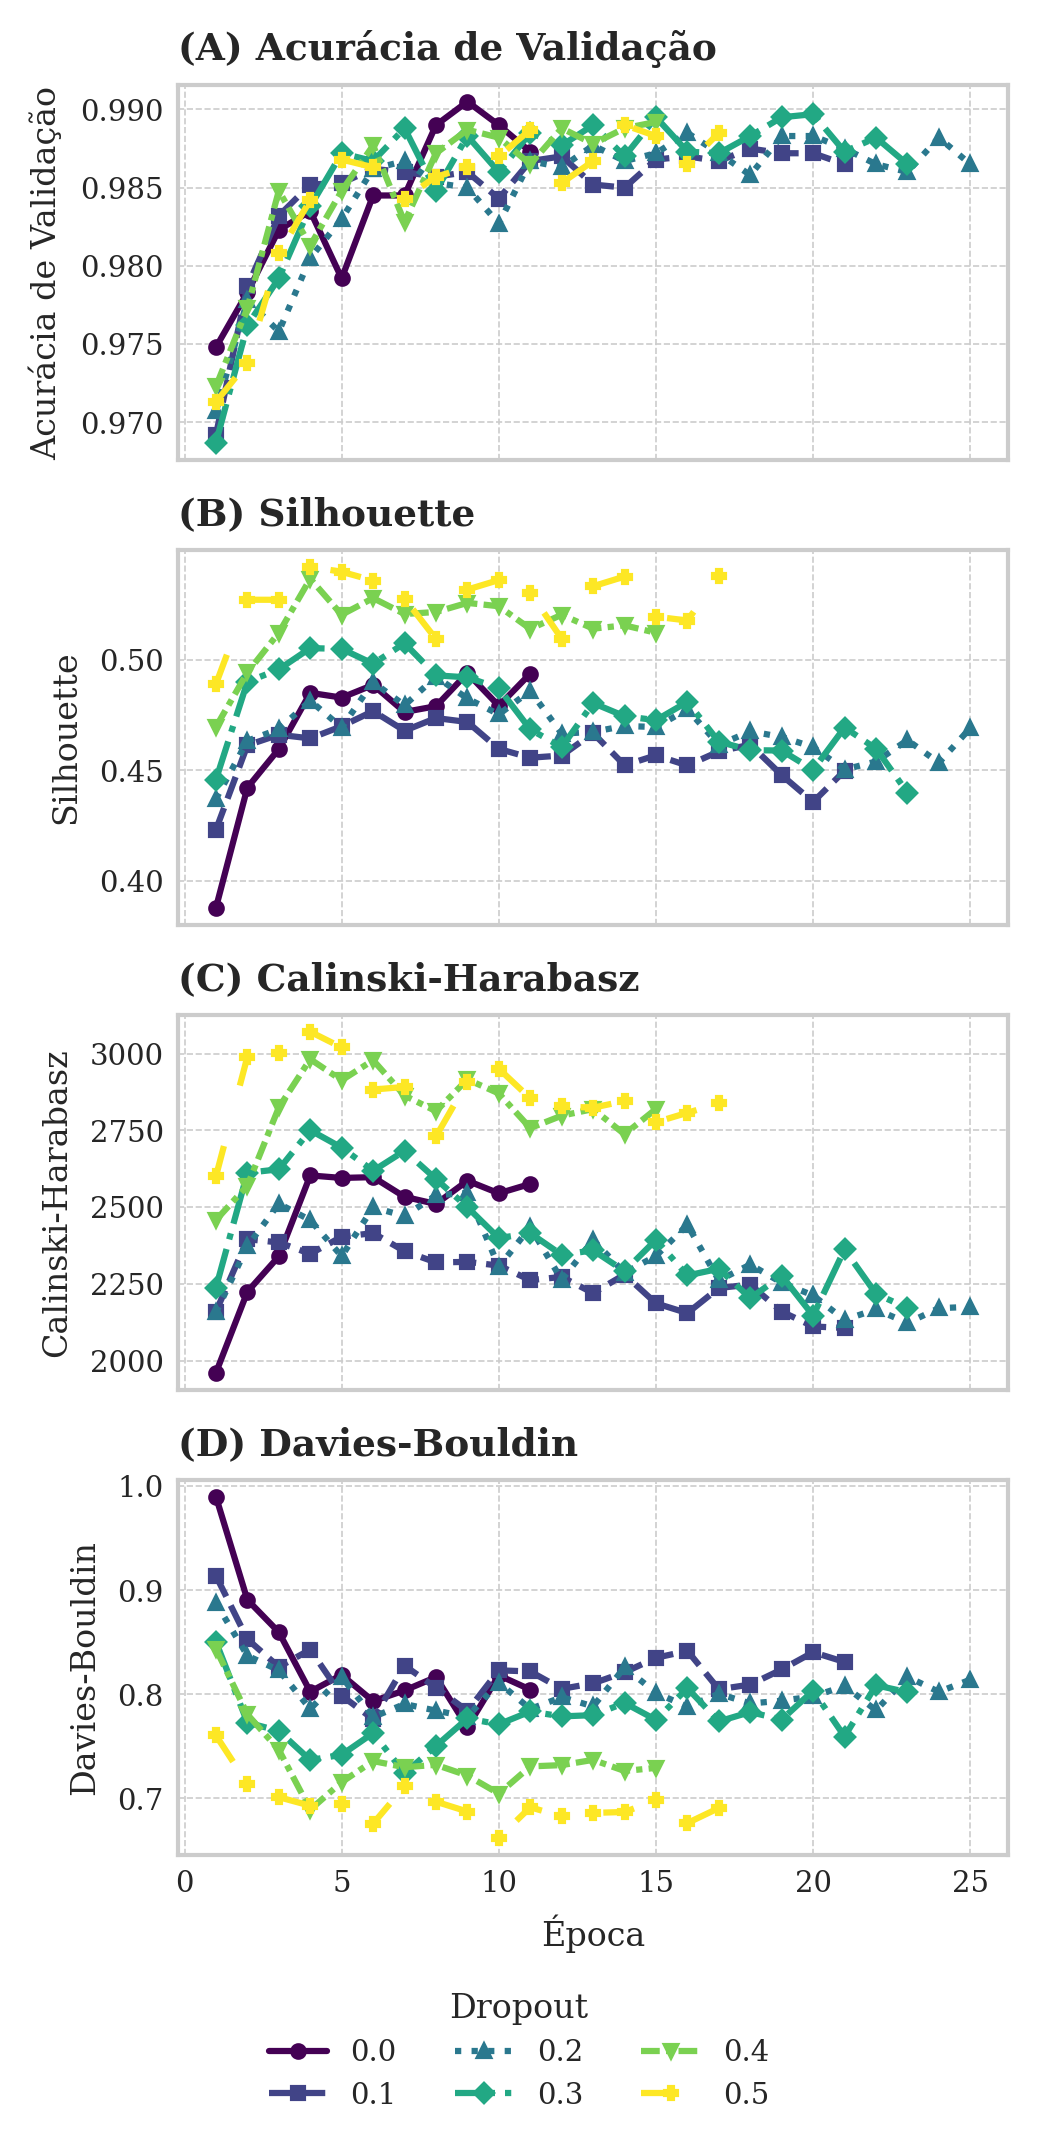

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

# --- 1. Configurações para o Padrão IEEE ---
output_dir = "imagens/artigo3"
os.makedirs(output_dir, exist_ok=True)

# Estilo e fontes para publicação
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='serif', size=8)          # Fonte padrão para o texto
plt.rc('axes', titlesize=9, labelsize=8)        # Títulos e rótulos dos eixos
plt.rc('xtick', labelsize=7)                    # Rótulos do eixo X
plt.rc('ytick', labelsize=7)                    # Rótulos do eixo Y
plt.rc('legend', fontsize=7, title_fontsize=8)  # Texto e título da legenda

# --- 2. Preparação dos Dados e Métricas ---
metrics = ['val_acc', 'silhouette', 'calinski', 'davies']
metric_labels = {
    'val_acc': 'Acurácia de Validação',
    'silhouette': 'Silhouette',
    'calinski': 'Calinski-Harabasz',
    'davies': 'Davies-Bouldin'
}
dropouts = sorted(df_results['dropout'].unique())

# --- 3. Criação do Gráfico ---
fig, axes = plt.subplots(4, 1, figsize=(3.5, 7), sharex=True, dpi=300)

# Estilos visuais para distinção (cor, marcador, tipo de linha)
colors = plt.cm.viridis(np.linspace(0, 1, len(dropouts)))
markers = ['o', 's', '^', 'D', 'v', 'P']
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 10))]

for i, metric in enumerate(metrics):
    ax = axes[i]
    for j, dropout_val in enumerate(dropouts):
        # Garante que os dados estão ordenados por época para a linha ser correta
        df_subset = df_results[df_results['dropout'] == dropout_val].sort_values('epoch')
        
        ax.plot(
            df_subset['epoch'],
            df_subset[metric],
            color=colors[j],
            marker=markers[j % len(markers)],
            linestyle=linestyles[j % len(linestyles)],
            markersize=3,  # Marcadores menores e mais limpos
            label=f"{dropout_val:.1f}"
        )
        
    ax.set_ylabel(metric_labels[metric])
    ax.set_title(f'({chr(65+i)}) {metric_labels[metric]}', loc='left', weight='bold')
    ax.grid(True, which='both', linestyle='--', linewidth=0.4)

# --- 4. Legenda e Layout Final ---
handles, labels = axes[0].get_legend_handles_labels()
# Legenda horizontal, com 2 linhas, posicionada abaixo da figura
fig.legend(handles, labels, title='Dropout', ncol=len(dropouts)//2,
           loc='lower center', bbox_to_anchor=(0.5, -0.02), frameon=False)

axes[-1].set_xlabel('Época')
# Ajusta o layout para dar espaço para a legenda na parte inferior
fig.tight_layout(rect=[0, 0.05, 1, 1])

# --- 5. Salvar a Figura ---
file_path = os.path.join(output_dir, "metricas_evolucao_vs_epoca.png")
plt.savefig(file_path, bbox_inches='tight', dpi=300)

print(f"Gráfico aprimorado salvo em: {file_path}")
plt.show()

# Importante: Reseta as configurações do matplotlib para não afetar outros plots no notebook
plt.rcdefaults()

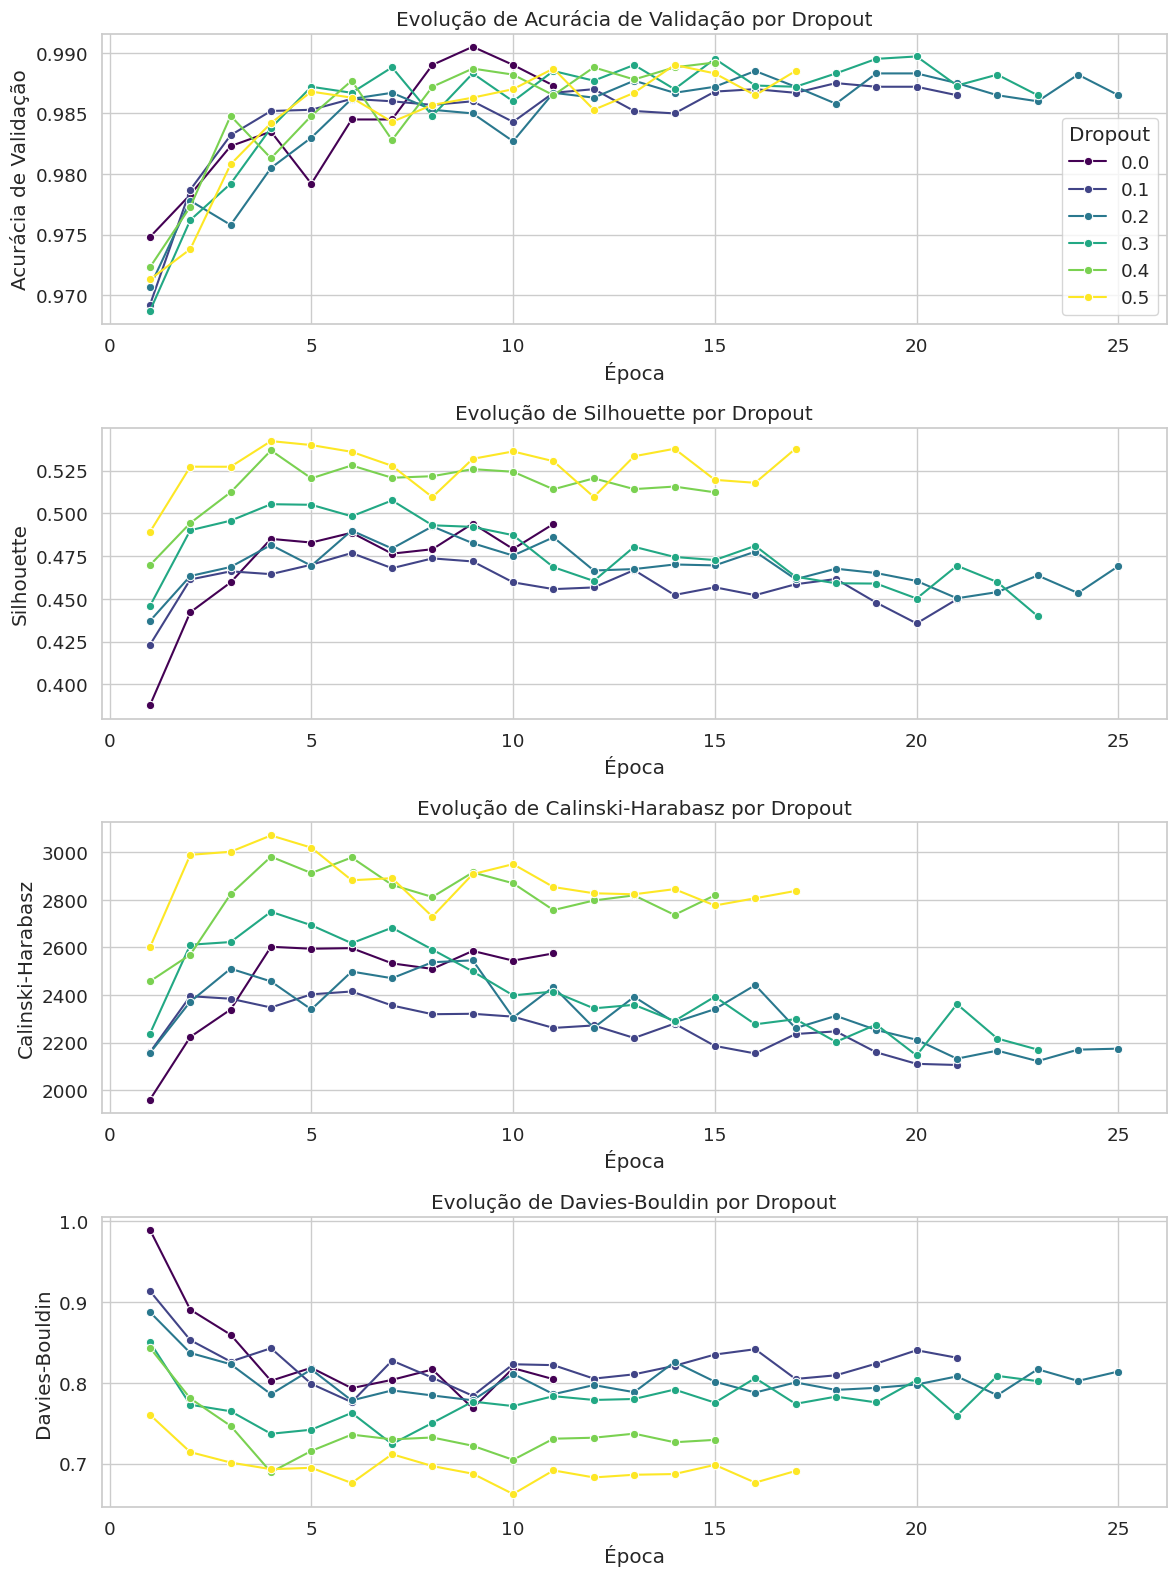

In [21]:
plt.figure(figsize=(12, 16))
metrics = ['val_acc', 'silhouette', 'calinski', 'davies']
metric_labels = {
    'val_acc': 'Acurácia de Validação',
    'silhouette': 'Silhouette',
    'calinski': 'Calinski-Harabasz',
    'davies': 'Davies-Bouldin'
}

for i, metric in enumerate(metrics):
    plt.subplot(4, 1, i+1)
    sns.lineplot(
        data=df_results,
        x='epoch', y=metric, hue='dropout', marker='o', palette='viridis'
    )
    plt.xlabel('Época')
    plt.ylabel(metric_labels[metric])
    plt.title(f'Evolução de {metric_labels[metric]} por Dropout')
    if i == 0:
        plt.legend(title='Dropout')
    else:
        plt.legend([],[], frameon=False)
    plt.grid(True)

plt.tight_layout()
plt.show()

Gráfico de boxplot salvo em: imagens/artigo3/metricas_boxplot_vs_dropout.png


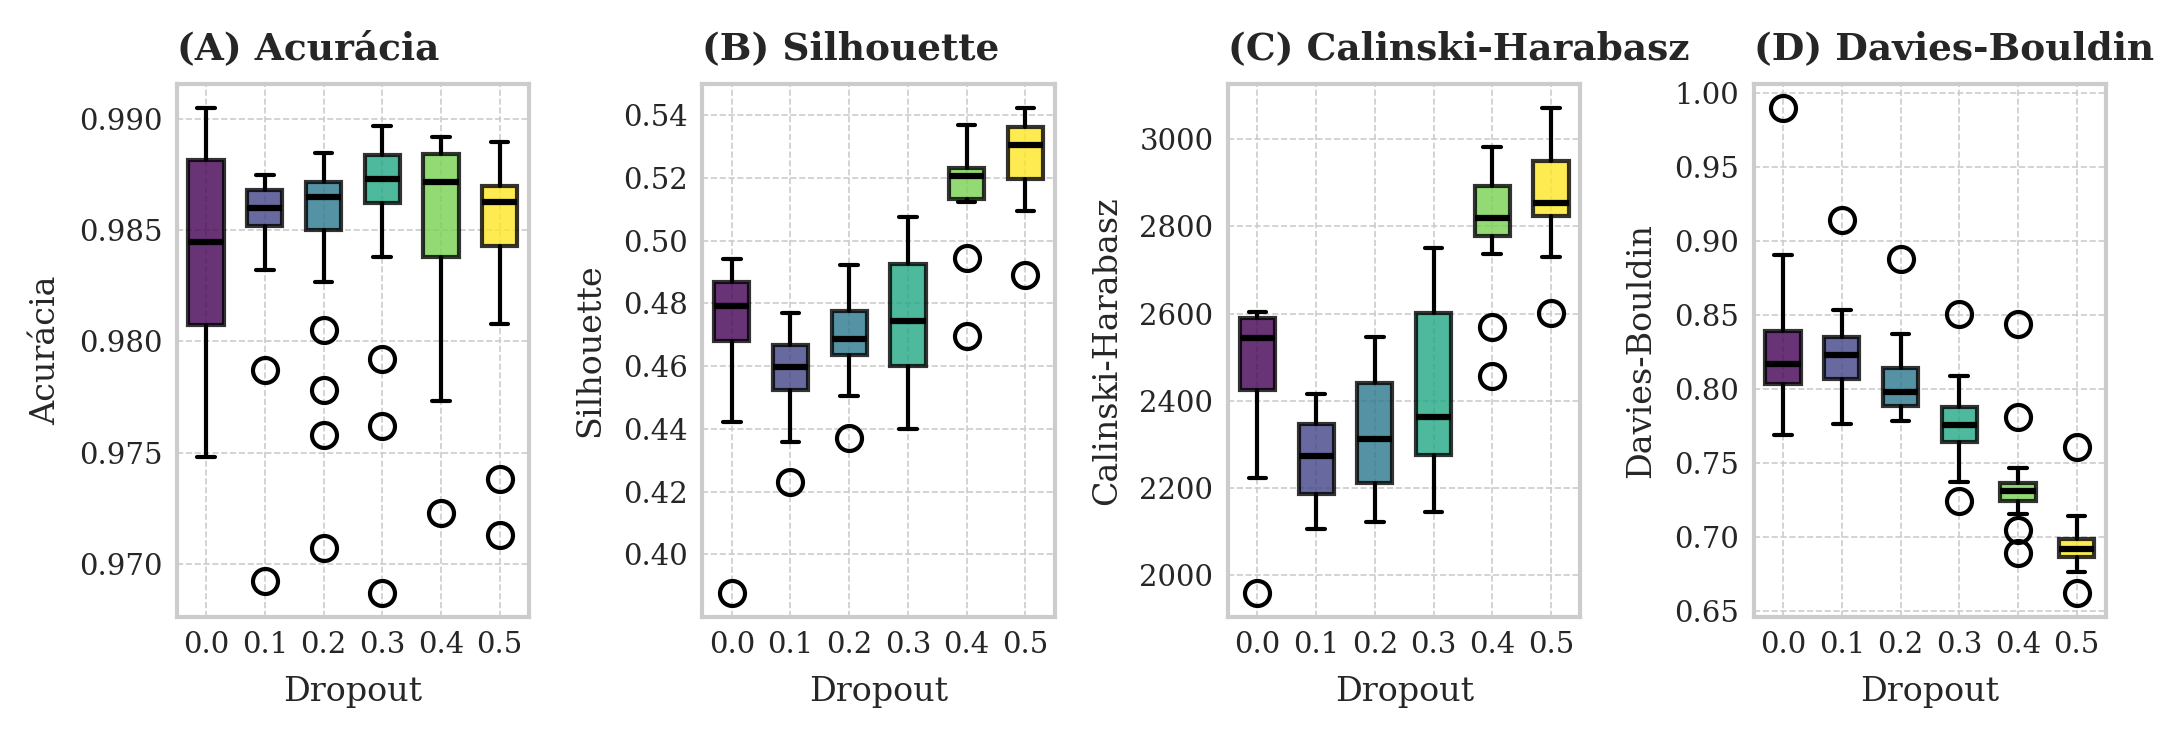

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

# --- 1. Configurações para o Padrão IEEE ---
output_dir = "imagens/artigo3"
os.makedirs(output_dir, exist_ok=True)

# Estilo e fontes para publicação
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='serif', size=8)
plt.rc('axes', titlesize=9, labelsize=8)
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)

# --- 2. Preparação dos Dados e Métricas ---
metrics = ['val_acc', 'silhouette', 'calinski', 'davies']
metric_labels = {
    'val_acc': 'Acurácia',
    'silhouette': 'Silhouette',
    'calinski': 'Calinski-Harabasz',
    'davies': 'Davies-Bouldin'
}
dropouts = sorted(df_results['dropout'].unique())

# --- 3. Criação do Gráfico ---
# Tamanho da figura (7.16 polegadas é a largura total da página no IEEE)
fig, axes = plt.subplots(1, 4, figsize=(7.16, 2.5), dpi=300)

colors = plt.cm.viridis(np.linspace(0, 1, len(dropouts)))

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    data_to_plot = [df_results[df_results['dropout'] == d][metric].dropna().values for d in dropouts]
    
    bp = ax.boxplot(
        data_to_plot,
        positions=np.arange(len(dropouts)),
        patch_artist=True,
        widths=0.6
    )
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)
        
    ax.set_xticks(np.arange(len(dropouts)))
    ax.set_xticklabels([f"{d:.1f}" for d in dropouts])
    ax.set_xlabel('Dropout')
    ax.set_ylabel(metric_labels[metric])
    ax.set_title(f'({chr(65+i)}) {metric_labels[metric]}', loc='left', weight='bold')
    ax.grid(True, which='both', linestyle='--', linewidth=0.4)

# --- 4. Layout Final e Salvamento ---
plt.tight_layout()

# Altera a extensão do arquivo para .png
file_path = os.path.join(output_dir, "metricas_boxplot_vs_dropout.png")
# Salva com DPI alto para garantir a qualidade
plt.savefig(file_path, dpi=300, bbox_inches='tight')

print(f"Gráfico de boxplot salvo em: {file_path}")
plt.show()

# Importante: Reseta as configurações do matplotlib
plt.rcdefaults()

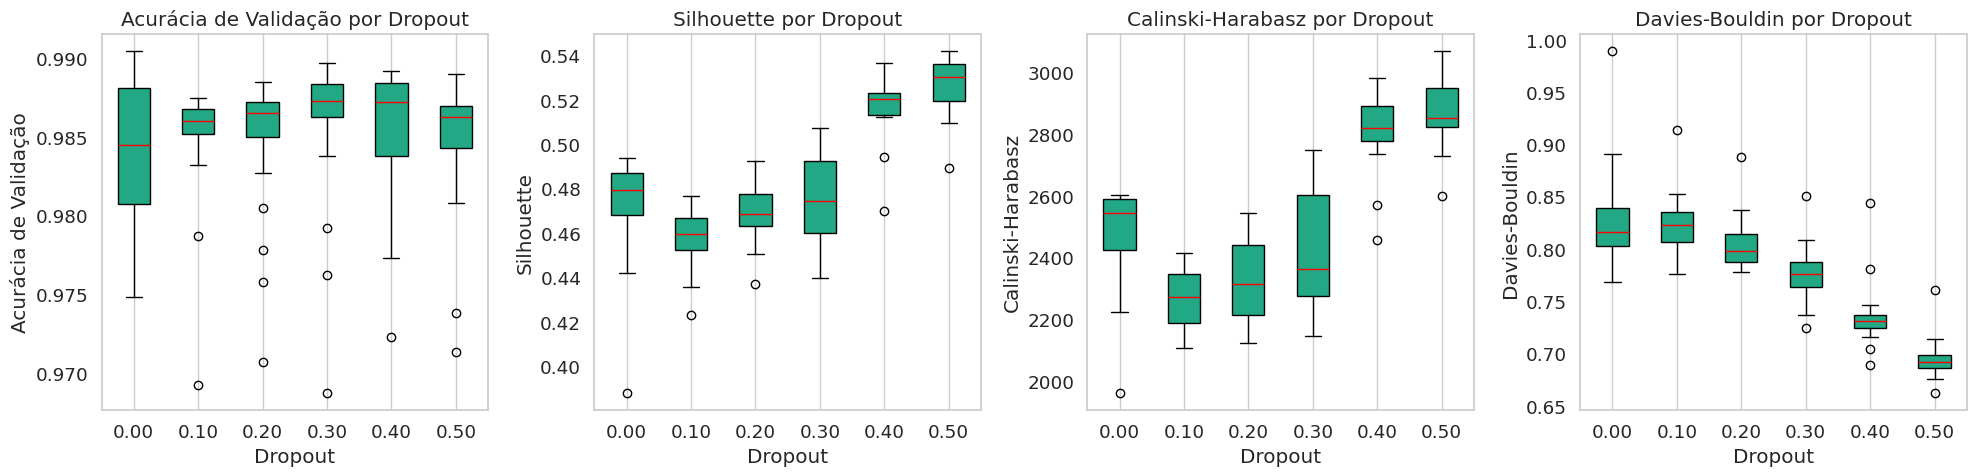

In [13]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['val_acc', 'silhouette', 'calinski', 'davies']
metric_labels = [
    'Acurácia de Validação',
    'Silhouette',
    'Calinski-Harabasz',
    'Davies-Bouldin'
]

dropouts = sorted(df_results['dropout'].unique())
n_dropouts = len(dropouts)

plt.figure(figsize=(5 * len(metrics), 5))  # Largura proporcional ao número de métricas

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    plt.subplot(1, len(metrics), i+1)
    data = [df_results[df_results['dropout'] == d][metric].values for d in dropouts]
    plt.boxplot(data, positions=np.arange(n_dropouts), patch_artist=True,
                boxprops=dict(facecolor=plt.cm.viridis(0.6), color='black'),
                medianprops=dict(color='red'))
    plt.xticks(np.arange(n_dropouts), [f"{d:.2f}" for d in dropouts])
    plt.xlabel('Dropout')
    plt.ylabel(label)
    plt.title(f'{label} por Dropout')
    plt.grid(axis='y')

plt.tight_layout()
plt.show()

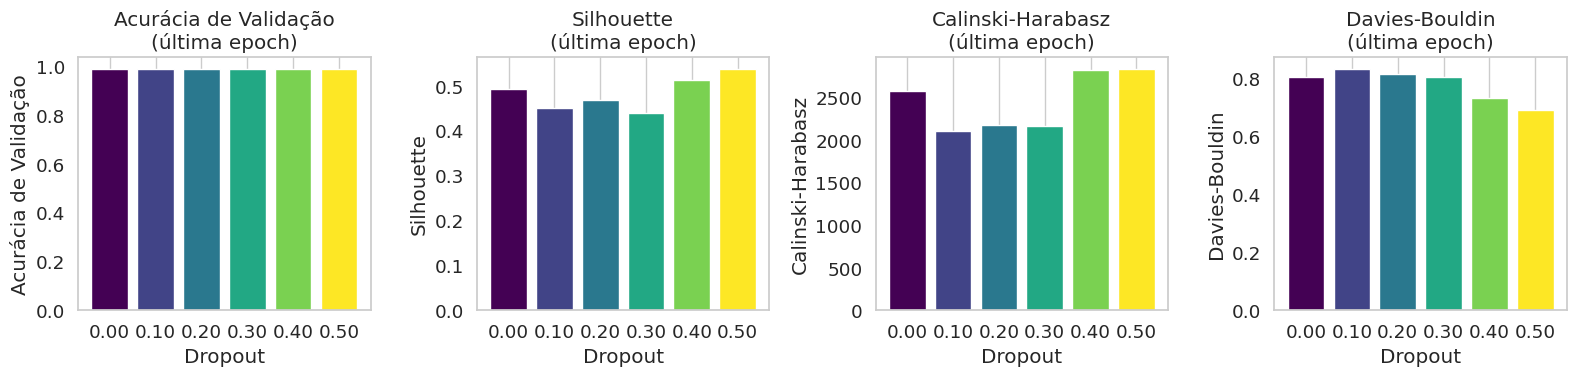

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Seleciona a última epoch de cada dropout
df_last = df_results.loc[df_results.groupby('dropout')['epoch'].idxmax()]

metrics = ['val_acc', 'silhouette', 'calinski', 'davies']
metric_labels = [
    'Acurácia de Validação',
    'Silhouette',
    'Calinski-Harabasz',
    'Davies-Bouldin'
]

dropouts = df_last['dropout'].values
x = np.arange(len(dropouts))

plt.figure(figsize=(16, 4))
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    plt.subplot(1, 4, i+1)
    plt.bar(x, df_last[metric], color=plt.cm.viridis((df_last['dropout']-min(dropouts))/(max(dropouts)-min(dropouts))))
    plt.xticks(x, [f"{d:.2f}" for d in dropouts])
    plt.xlabel('Dropout')
    plt.ylabel(label)
    plt.title(f'{label}\n(última epoch)')
    plt.grid(axis='y')

plt.tight_layout()
plt.show()

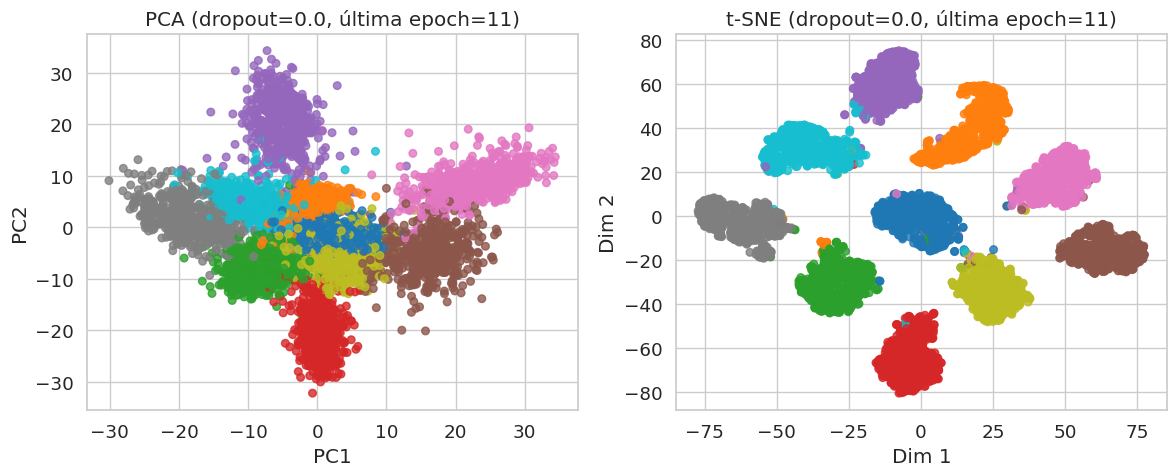

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Filtra para dropout=0.0 e última epoch
valor_dropout = 0.0
ultima_epoch = df[df['dropout'] == valor_dropout]['epoch'].max()
df_plot = df[(df['dropout'] == valor_dropout) & (df['epoch'] == ultima_epoch)]

embeddings = np.stack(df_plot['embedding'].values)
labels = df_plot['label'].values

# Redução PCA
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

# Redução t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_tsne = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=labels, cmap='tab10', s=30, alpha=0.8)
plt.title(f'PCA (dropout={valor_dropout}, última epoch={ultima_epoch})')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(1, 2, 2)
plt.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], c=labels, cmap='tab10', s=30, alpha=0.8)
plt.title(f't-SNE (dropout={valor_dropout}, última epoch={ultima_epoch})')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')

plt.tight_layout()
plt.show()